In [1]:
from sqlalchemy import column

#linear regression
'''لما بكون عايزة اتنبا بقيمة مستمرة عايزة اتوقع هي زادت او نقصت بقيمة قد ايه دي linear regression '''
''' ال target بتاعي بيكون dependent اما ال feature بتاعتي بتكون independent
ال linear regrssion بيحسب خط يناسب القرائات اللي موجودة او الداتا بتاعتي بمعني اصح
عمليا دا مستحيل فبنعمل ايه بقا بدالها .... اننا بناخد اقل مسافة تقللي نسبة ال error فبيحسب المسافة مبين كل data point  '''


' ال target بتاعي بيكون dependent اما ال feature بتاعتي بتكون independent\nال linear regrssion بيحسب خط يناسب القرائات اللي موجودة او الداتا بتاعتي بمعني اصح\nعمليا دا مستحيل فبنعمل ايه بقا بدالها .... اننا بناخد اقل مسافة تقللي نسبة ال error فبيحسب المسافة مبين كل data point  '

Housing prediction

In [2]:
# importing the appropriate library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing


In [3]:
housing = fetch_california_housing()

In [4]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [5]:
'''extracting the dataset from housing and convert it into data frame'''
df = pd.DataFrame(housing.data,columns=housing.feature_names)

In [6]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [7]:
'''adding data to the data frame'''
df['PRICE'] = housing.target

In [8]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


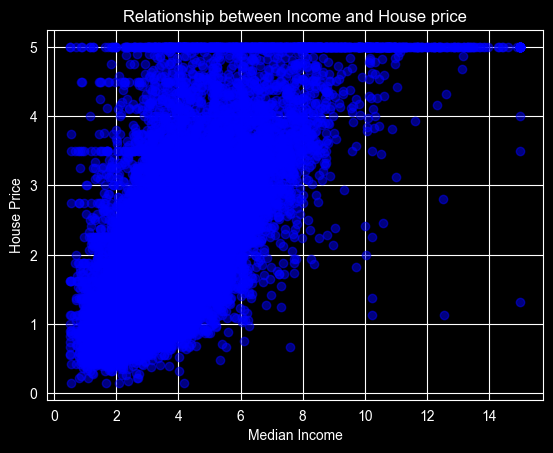

In [9]:
''' extract features from the data frame '''
plt.scatter(df['MedInc'],df['PRICE'],color='blue',alpha=0.5)
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.title('Relationship between Income and House price')
plt.show()

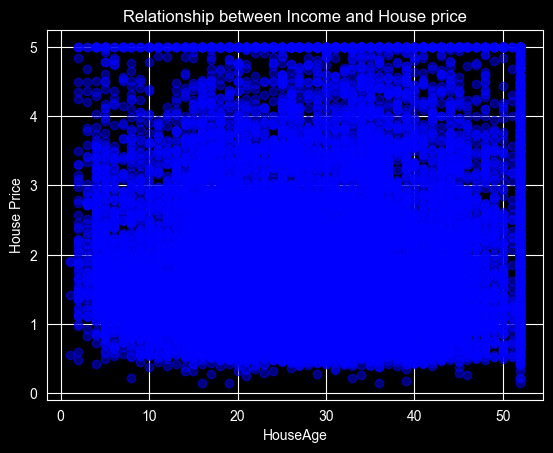

In [10]:
''' extract features from the data frame '''
plt.scatter(df['HouseAge'],df['PRICE'],color='blue',alpha=0.5)
plt.xlabel('HouseAge')
plt.ylabel('House Price')
plt.title('Relationship between Income and House price')
plt.show()

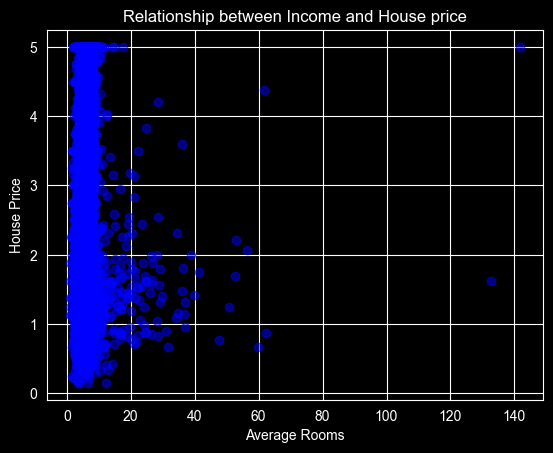

In [11]:
plt.scatter(df['AveRooms'],df['PRICE'],color='blue', alpha=0.5)
plt.xlabel('Average Rooms')
plt.ylabel('House Price')
plt.ylabel('House Price')
plt.title('Relationship between Income and House price')
plt.show()

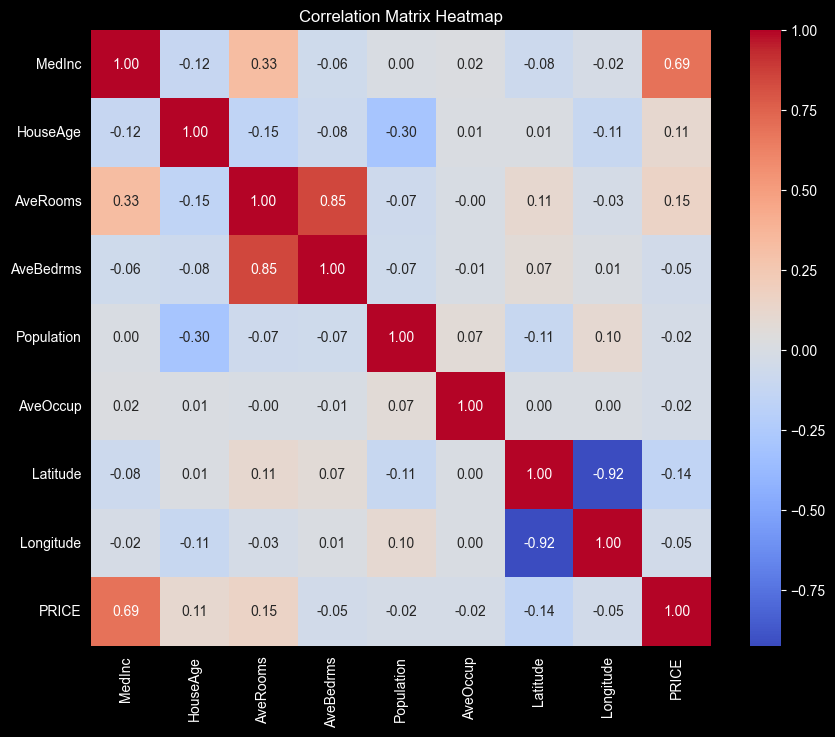

In [12]:
'''heat map of all the features without the lattitude nor longitude'''
#heatmap without the latitude and longitude
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

In [13]:
correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
PRICE,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


In [14]:
features_to_explore = ['MedInc','AveRooms', 'HouseAge','Population']

In [15]:
'''Preparation for the data'''
selected_features = ['MedInc','AveRooms', 'HouseAge','Population', 'AveRooms', "AveBedrms"]

In [16]:
X = df[selected_features]
y = df['PRICE']

In [17]:
X

,MedInc,AveRooms,HouseAge,Population,AveRooms,AveBedrms
0,8.3252,6.984127,41.0,322.0,6.984127,1.023810
1,8.3014,6.238137,21.0,2401.0,6.238137,0.971880
2,7.2574,8.288136,52.0,496.0,8.288136,1.073446
3,5.6431,5.817352,52.0,558.0,5.817352,1.073059
4,3.8462,6.281853,52.0,565.0,6.281853,1.081081
...,...,...,...,...,...,...
20635,1.5603,5.045455,25.0,845.0,5.045455,1.133333
20636,2.5568,6.114035,18.0,356.0,6.114035,1.315789
20637,1.7000,5.205543,17.0,1007.0,5.205543,1.120092
20638,1.8672,5.329513,18.0,741.0,5.329513,1.171920


In [18]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: PRICE, Length: 20640, dtype: float64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
''' 0.2 دي هي ال 20 فى المية اللي الداتا هتعمل عليهم test'''



' 0.2 دي هي ال 20 فى المية اللي الداتا هتعمل عليهم test'

## train model

In [20]:
model = LinearRegression()
model.fit(X_train,y_train)

''' function [ .fit() ] مسؤلة عن تدريب الموديل '''

' function [ .fit() ] مسؤلة عن تدريب الموديل '

## make prediction

In [21]:
y_pred = model.predict(X_test)

In [22]:
print("Comparison of Actual vs Predicted Prices")
for actual, predicted in list(zip(y_test[:10], y_pred[:10])):
    print("Actual:", round(actual, 2), " | Predicted:", round(predicted, 2))

Comparison of Actual vs Predicted Prices
Actual: 0.48  | Predicted: 1.01
Actual: 0.46  | Predicted: 1.56
Actual: 5.0  | Predicted: 2.66
Actual: 2.19  | Predicted: 2.65
Actual: 2.78  | Predicted: 1.98
Actual: 1.59  | Predicted: 2.18
Actual: 1.98  | Predicted: 2.66
Actual: 1.57  | Predicted: 2.17
Actual: 3.4  | Predicted: 2.43
Actual: 4.47  | Predicted: 4.23


## Evaluate

In [25]:
r2 = r2_score(y_test, y_pred)

''' r2_score() بتحدد نسبة فهم الموديل للداتا  '''

' r2_score() بتحدد نسبة فهم الموديل للداتا  '

In [24]:
r2

0.5089947802907755